In [ ]:
import pandas as pd
from langchain.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from typing import List, Annotated, Optional, Union, Literal
from langgraph.graph import StateGraph, START, END
from langchain_community.document_loaders import PDFPlumberLoader
from pathlib import Path
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
import json

from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
load_dotenv()
import google.generativeai as genai
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

class User(BaseModel):
    username: str = Field(..., description="Generated username")
    email: str = Field(..., description="User's email")
    designation: str = Field(..., description="User's designation in the company")
    department: str = Field(..., description="Department name")
    phone: str = Field(..., description="User phone details")

class Address(BaseModel):
    address1: str
    address2: Optional[str]
    city: str
    state: str
    zip: str
    country: Optional[str]
    county: Optional[str]

class Customer(BaseModel):
    id: int
    name: str
    address: Address

class Office(BaseModel):
    id: int
    location: str
    size: int

llm = ChatGoogleGenerativeAI(model="models/gemini-1.5-flash", temperature=0.0)

class IntentEntityPath(BaseModel):
    intent: Literal["add", "delete"] = Field(description="The classified intent.")
    entity: Literal["user", "customer", 'office'] = Field(description="The classified entity.")
    file_path: str

def detect_intent(state):
    "This node will detect intent"
    chat_input = state['messages'][-1].content
    response = llm.with_structured_output(IntentEntityPath).invoke(chat_input)
    return {'file_path': response.file_path, 'output_schema': response.entity}


def read_file(state):
    "This node will read the file and extract data from the file path"

    file_ext = Path(state['file_path']).suffix

    if file_ext == '.csv':
        df = pd.read_csv(state['file_path'])
        return {'file_content': df.to_dict(orient="records")}

    if file_ext == '.xlsx':
        df = pd.read_excel(state['file_path'])
        return {'file_content': df.to_dict(orient="records")}

    if file_ext == '.pdf':
        loader = PDFPlumberLoader(state['file_path'])
        return {'file_content': loader.load()}

    else: return {'file_content': state['raw_input']}

def interpret(state):
    prompt = f"""
    Given this raw user data: {state['file_content']}, extract and map it to the Entitylist format.
    Take appropriate instructions from the user input only if necessary: {state['messages'][-1].content}
    """
    if state['output_schema'] == 'customer':
        class Entitylist(BaseModel):
            entities: list[Customer]
    if state['output_schema'] == 'user':
        class Entitylist(BaseModel):
            entities: list[User]
    if state['output_schema'] == 'office':
        class Entitylist(BaseModel):
            entities: list[Office]

    response = llm.with_structured_output(Entitylist).invoke(prompt)
    print(response)
    return {'result_json': response}

class GraphState(MessagesState):
    """
    Graph state is a dictionary that contains information we want to propagate to, and modify in, each graph node.
    """

    file_path: Optional[str]
    raw_input: Optional[str]
    file_content: Union[dict, list, str]
    output_schema: str
    result_json: dict

graph = StateGraph(GraphState)

graph.add_node("detect_intent", detect_intent)
graph.add_node("read_file", read_file)
graph.add_node("interpret", interpret)

graph.add_edge(START, "detect_intent")
graph.add_edge("detect_intent", "read_file")
graph.add_edge("read_file", "interpret")
graph.add_edge("interpret", END)

workflow = graph.compile()

def get_output(chat_input):
    #chat_input = "Add just the top 3 users from users.csv file."
    output = workflow.invoke({'messages': HumanMessage(content=chat_input)})
    new_users = output['result_json'].entities
    new_users_dicts = [user.dict() for user in new_users]

    if output['output_schema'] == 'user':
        json_file_path = r'users.json'
    if output['output_schema'] == 'customer':
        json_file_path = r'customers.json'
    if output['output_schema'] == 'office':
        json_file_path = r'offices.json'

    with open(json_file_path, 'r') as file:
        existing_data = json.load(file)

    existing_data.extend(new_users_dicts)
    with open(json_file_path, 'w') as file:
        json.dump(existing_data, file, indent=4)

    print(new_users)
    return new_users

get_output("Add just the top 3 users from users.csv file.")


In [ ]:
import streamlit as st
import time
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from functions_models import detect_intent, read_file, interpret, add, delete, router, general_chat, GraphState

graph = StateGraph(GraphState)

graph.add_node("detect_intent", detect_intent)
graph.add_node("read_file", read_file)
graph.add_node("interpret", interpret)
graph.add_node("add", add)
graph.add_node("delete", delete)
graph.add_node("general_chat", general_chat)

graph.add_edge(START, "detect_intent")
graph.add_conditional_edges("detect_intent", router)
graph.add_edge("read_file", "interpret")
graph.add_edge("interpret", "add")
graph.add_edge("add", END)
graph.add_edge("delete", END)
graph.add_edge("general_chat", END)

checkpointer = MemorySaver()
config = {"configurable": {"thread_id": "1"}}
workflow = graph.compile(checkpointer=checkpointer)

/media/mowne/New Volume/projects/erp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


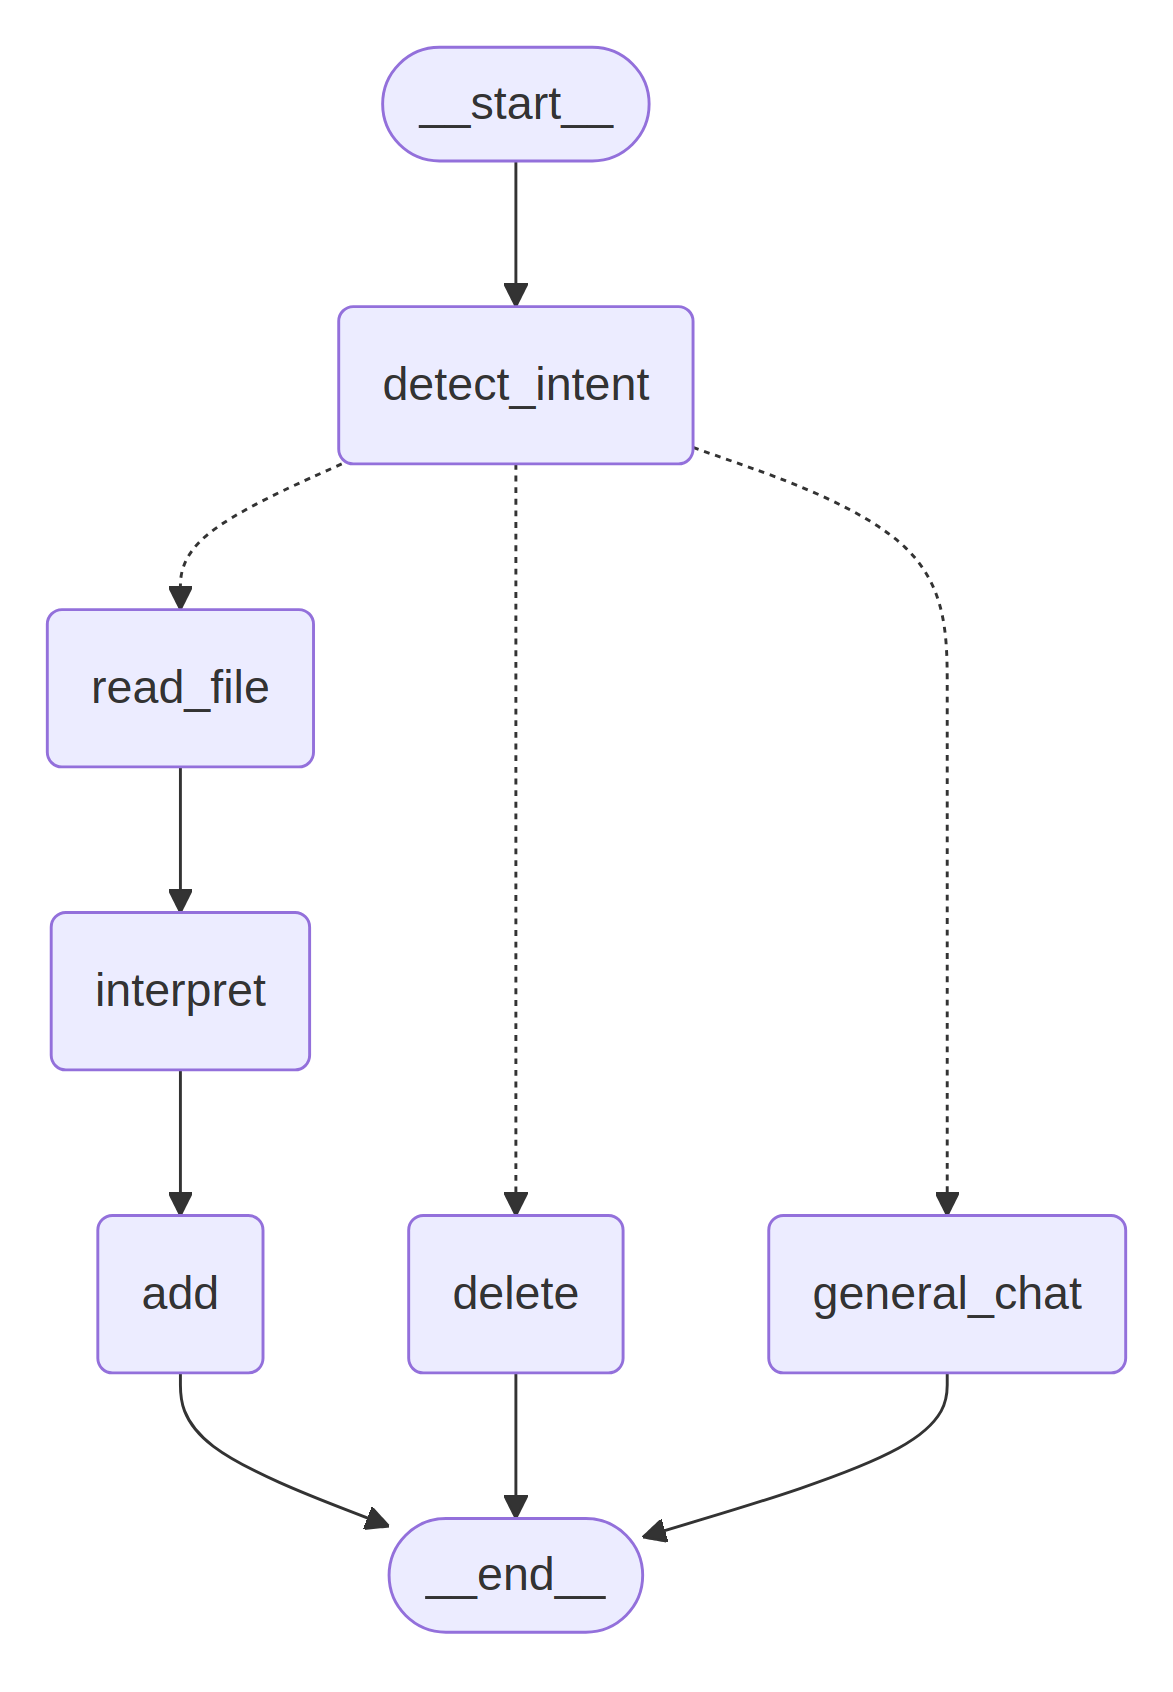

In [2]:
import nest_asyncio
from langchain_core.runnables.graph import CurveStyle,MermaidDrawMethod, NodeStyles
from IPython.display import Image, display

nest_asyncio.apply()  # Required for Jupyter Notebook to run async functions

display(
    Image(
        workflow.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9",
default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=5,
        )
    )
)


In [5]:
!pip install pyppeteer

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for websockets: filename=websockets-10.4-cp312-cp312-linux_x86_64.whl size=95056 sha256=895f54a18c68afdf857b0c610ebef942f8b91128ebb32dc92d011edbce94e2c4
  Stored in directory: /home/mowne/.cache/pip/wheels/80/cf/6d/5d7e4c920cb41925a178b2d2621889c520d648bab487b1d7fd
Successfully built websockets
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.3.0
    Uninstalling urllib3-2.3.0:
      Successfully uninstalled urllib3-2.3.0


In [12]:
import requests

response = requests.post("http://127.0.0.1:8000/chat/", json= {"chat_input": "Summarize our conversation so far"})
print(response.json())

We started with introductions, where I identified myself as a database assistant capable of adding, deleting, and modifying users, customers, and offices within a database.  I provided examples of commands I could understand.  Finally, you requested the deletion of a customer with ID 17, which I confirmed as successfully completed.


In [1]:
from graphviz import Digraph
import json

# Load the JSON data
data = {
    "employees": [
        {"id": "1", "name": "John Doe", "position": "CEO", "reportees": ["2", "3", "4"]},
        {"id": "2", "name": "Jane Smith", "position": "CTO", "reportees": ["5", "6"]},
        {"id": "3", "name": "Michael Green", "position": "CFO", "reportees": ["7", "8"]},
        {"id": "4", "name": "Emily Davis", "position": "COO", "reportees": ["9", "10"]},
        {"id": "5", "name": "Alice Johnson", "position": "Senior Software Engineer", "reportees": []},
        {"id": "6", "name": "Bob Brown", "position": "Software Engineer", "reportees": []},
        {"id": "7", "name": "Sarah White", "position": "Finance Manager", "reportees": []},
        {"id": "8", "name": "Tom Black", "position": "Accountant", "reportees": []},
        {"id": "9", "name": "Karen Wilson", "position": "Operations Manager", "reportees": []},
        {"id": "10", "name": "Chris Taylor", "position": "Logistics Coordinator", "reportees": []}
    ]
}

# Create a dictionary for quick lookup
employee_dict = {employee['id']: employee for employee in data['employees']}

# Initialize a directed graph
dot = Digraph(format='png')
dot.attr(rankdir='TB', size='10')

# Add nodes and edges
for employee in data['employees']:
    node_label = f"{employee['name']}\n({employee['position']})"
    dot.node(employee['id'], label=node_label, shape='box', style='rounded')

    for reportee_id in employee['reportees']:
        dot.edge(employee['id'], reportee_id)

# Render and view the graph
dot.render('org_chart', view=True)


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH